# Retail_Analytics & Customer_Segmentation_Using_RFM

## Data Cleaning, Feature Engineering

### 1. Load Dataset

In [40]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [13]:
df=pd.read_excel(r'C:\Users\Admin\Documents\Rinsha\Data Analysis Project\SuperStore\Data\Super-Store Dataset.xlsx')

In [14]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,731.9400,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",NaN,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [15]:
df.shape

(9994, 21)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [17]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9993.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.854788,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.480000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.276204,2.225110,0.206452,234.260108


### 2. Handle 'NULL' & Duplicate Values

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            1
Quantity         0
Discount         0
Profit           0
dtype: int64

In [13]:
df['Sales']=df['Sales'].fillna(value=df['Sales'].mean())

In [15]:
df['Sales']

0       731.940000
1       229.854788
2        14.620000
3       957.577500
4        22.368000
           ...    
9989     25.248000
9990     91.960000
9991    258.576000
9992     29.600000
9993    243.160000
Name: Sales, Length: 9994, dtype: float64

In [14]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [20]:
# Percentage of Missing Values
missing_percentage = (df.isnull().sum() / len(df)) * 100

In [21]:
missing_percentage

Row ID           0.000000
Order ID         0.000000
Order Date       0.000000
Ship Date        0.000000
Ship Mode        0.000000
Customer ID      0.000000
Customer Name    0.000000
Segment          0.000000
Country          0.000000
City             0.000000
State            0.000000
Postal Code      0.000000
Region           0.000000
Product ID       0.000000
Category         0.000000
Sub-Category     0.000000
Product Name     0.000000
Sales            0.010006
Quantity         0.000000
Discount         0.000000
Profit           0.000000
dtype: float64

In [27]:
# Check Negative Sales Values
negative_sales = df[df['Sales'] < 0]

# Display Result
if negative_sales.empty:
    print("No Negative Sales Records Found")
else:
    print("Negative Sales Records:")
    print(negative_sales)

No Negative Sales Records Found


In [28]:
# Check Invalid Quantity Values
invalid_quantity = df[df['Quantity'] <= 0]

# Display Result
if invalid_quantity.empty:
    print("No Invalid Quantity Records Found")
else:
    print("Invalid Quantity Records:")
    print(invalid_quantity)

No Invalid Quantity Records Found


In [33]:
#"Data Types Before Conversion:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [34]:
# Convert Numeric Columns if Needed
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')
df['Profit'] = pd.to_numeric(df['Profit'], errors='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Discount'] = pd.to_numeric(df['Discount'], errors='coerce')

In [35]:
#Data Types After Validation:"
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

## OUTLIER DETECTION 

In [57]:

# Using IQR Method for Sales Column
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[(df['Sales'] < lower_limit) | 
              (df['Sales'] > upper_limit)]

outliers.shape[0]


1167

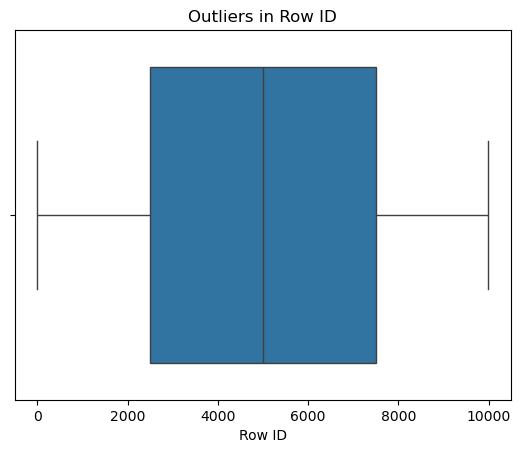

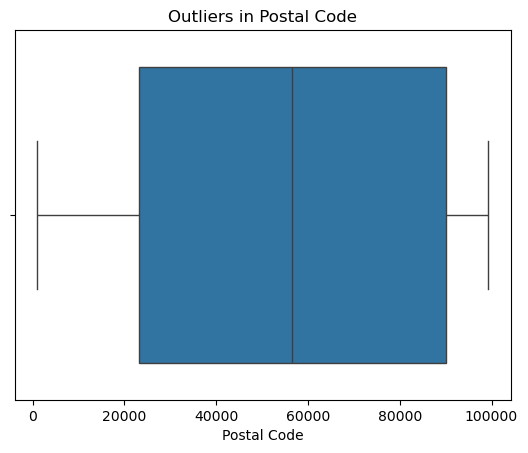

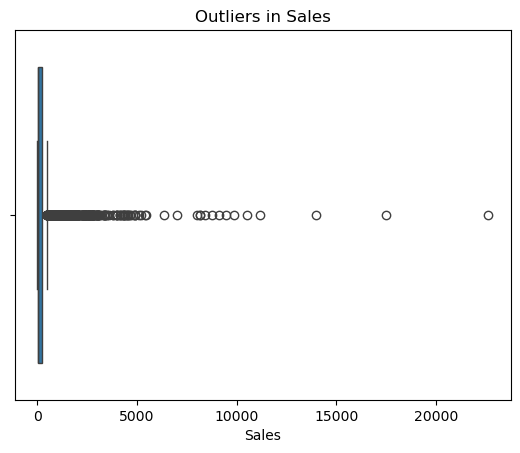

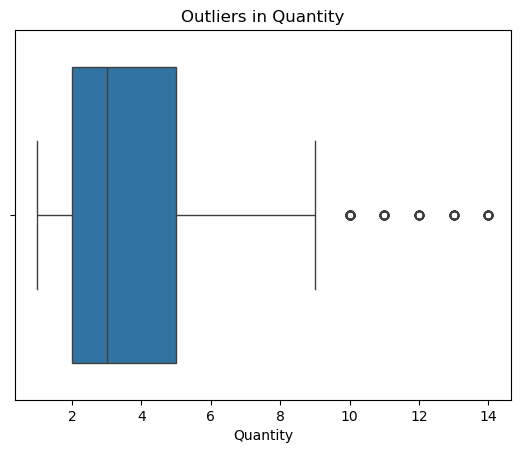

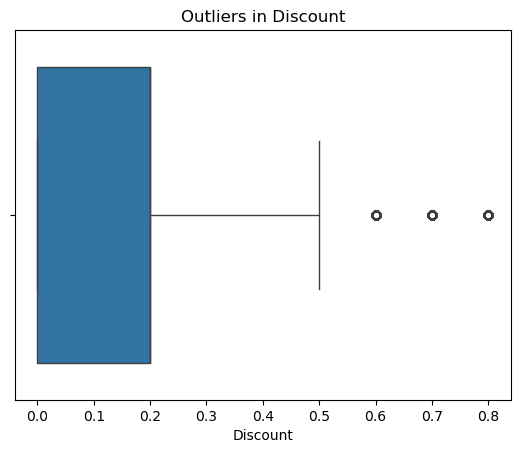

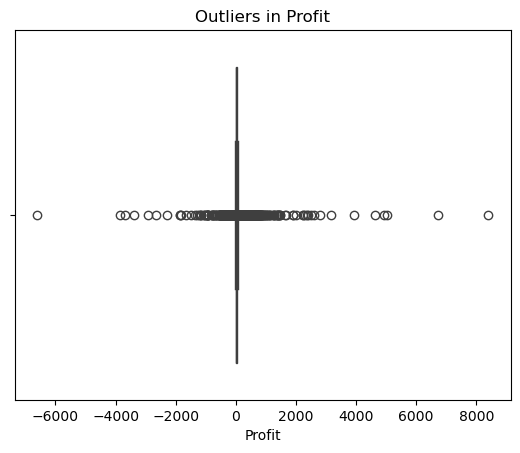

In [58]:
num_cols=df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Outliers in {col}")
    plt.show()

# RFM Analysis

In [43]:
reference_date = df['Order Date'].max() + pd.Timedelta(days=1)

In [45]:
rfm = df.groupby('Customer ID').agg({
    'Order Date': lambda x: (reference_date - x.max()).days,  # Recency
    'Order ID': 'nunique',                                   # Frequency
    'Sales': 'sum'                                       # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [46]:
# Recency (lower is better → reverse labels)
rfm['R_score'] = pd.qcut(
    rfm['Recency'],
    q=4,
    labels=[4,3,2,1],
    duplicates='drop'
)

# Frequency (higher is better)
rfm['F_score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    q=4,
    labels=[1,2,3,4]
)

# Monetary (higher is better)
rfm['M_score'] = pd.qcut(
    rfm['Monetary'].rank(method='first'),
    q=4,
    labels=[1,2,3,4]
)

In [48]:
rfm['RFM_Score'] = (rfm['R_score'].astype(str) +
                    rfm['F_score'].astype(str) +
                    rfm['M_score'].astype(str))

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
Customer ID,,,,,,,
AA-10315,185,5,5563.560,1,1,4,114
AA-10375,20,9,1056.390,4,4,1,441
AA-10480,260,4,1790.512,1,1,2,112
AA-10645,56,6,5086.935,3,2,4,324
AB-10015,416,3,886.156,1,1,1,111


## CUSTOMER SEGMENTATION

In [51]:
def customer_segment(row):

    if row['RFM_Score'] == '444':
        return 'Best Customers'

    elif row['R_score'] == 4:
        return 'Recent Customers'

    elif row['F_score'] == 4:
        return 'Loyal Customers'

    elif row['M_score'] == 4:
        return 'High Spending Customers'

    else:
        return 'Regular Customers'


In [52]:
# Apply Segmentation
rfm['Customer Segment'] = rfm.apply(customer_segment,
                                    axis=1)


In [53]:
# SEGMENT COUNTS
segment_counts = rfm['Customer Segment'].value_counts()

segment_counts

Customer Segment
Regular Customers          379
Recent Customers           169
Loyal Customers            125
High Spending Customers     86
Best Customers              34
Name: count, dtype: int64

In [55]:
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Customer Segment
Customer ID,,,,,,,,
AA-10315,185,5,5563.560,1,1,4,114,High Spending Customers
AA-10375,20,9,1056.390,4,4,1,441,Recent Customers
AA-10480,260,4,1790.512,1,1,2,112,Regular Customers
AA-10645,56,6,5086.935,3,2,4,324,High Spending Customers
AB-10015,416,3,886.156,1,1,1,111,Regular Customers


In [56]:
# Save Cleaned Dataset
df.to_excel("Cleaned_SuperStore_Dataset.xlsx",
            index=False)

# Save RFM Analysis
rfm.to_excel("RFM_Analysis.xlsx")

print("Files Saved Successfully")

Files Saved Successfully
